# A — Scenario Diversity Influence Confirmation

固定Actor・同一総rollout数で、**同一geometry反復**と**geometry多様化**を比較します。Bは10 geometry/N×10回、Cは100 geometry/N×1回、held-outは20 geometry/N×3回です。Cost Critic seed 0/1/2を共通初期値で比較します。

In [1]:
from pathlib import Path
from copy import deepcopy
import gc, hashlib, json, math, platform, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / 'uav_safe_marl').is_dir(): ROOT = ROOT.parent
SOURCE_RUN = ROOT / 'runs' / 'mini_pilot_episodic_dcost6_mps'
SOURCE_CHECKPOINT = SOURCE_RUN / 'checkpoints' / 'final.pt'
OUTPUT_RUN = ROOT / 'runs' / 'scenario_diversity_confirmation'
AGENT_COUNTS = [2, 4, 8]
B_UNIQUE_PER_N, B_REPEATS = 10, 10
C_UNIQUE_PER_N, C_REPEATS = 100, 1
VALIDATION_UNIQUE_PER_N, VALIDATION_REPEATS = 20, 3
COST_CRITIC_SEEDS = [0, 1, 2]
UPDATE_MILESTONES = [0, 1_000, 5_000, 10_000, 20_000]
TIMEOUT_MULTIPLIER = 2.0
REPLAY_CAPACITY = 200_000
REGENERATE_BANKS = False
RECOLLECT_TRAINING_DATA = False
RECOLLECT_VALIDATION = False
RETRAIN_COST_CRITICS = False
OUTPUT_RUN.mkdir(parents=True, exist_ok=True)
for path in (SOURCE_CHECKPOINT, SOURCE_RUN / 'resolved_config.json'):
    if not path.exists(): raise FileNotFoundError(path)
SOURCE_SHA256 = hashlib.sha256(SOURCE_CHECKPOINT.read_bytes()).hexdigest()
print({'source': str(SOURCE_CHECKPOINT), 'output': str(OUTPUT_RUN), 'cost_seeds': COST_CRITIC_SEEDS})

{'source': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/mini_pilot_episodic_dcost6_mps/checkpoints/final.pt', 'output': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/scenario_diversity_confirmation', 'cost_seeds': [0, 1, 2]}


In [2]:
print({'platform': platform.platform(), 'torch': torch.__version__, 'mps_available': torch.backends.mps.is_available()})
if not torch.backends.mps.is_available(): raise RuntimeError('VS Codeでプロジェクトの.venvカーネルを選択してください。')
probe = torch.ones((128, 128), device='mps'); print({'device': str(probe.device), 'probe': float((probe @ probe).sum().cpu())}); del probe

{'platform': 'macOS-15.6-arm64-arm-64bit-Mach-O', 'torch': '2.14.0', 'mps_available': True}
{'device': 'mps:0', 'probe': 2097152.0}


In [3]:
from uav_safe_marl import build_env, load_config
from uav_safe_marl.evaluation import generate_random_traffic_bank, load_scenario_bank, save_scenario_bank
from uav_safe_marl.runners.trainer import SafeRLTrainer
from uav_safe_marl.runners.evaluator import evaluate

resolved = json.loads((SOURCE_RUN / 'resolved_config.json').read_text(encoding='utf-8'))
resolved['device'] = 'mps'
resolved['learning']['buffer_size'] = REPLAY_CAPACITY
resolved['training']['total_environment_steps_budget'] = None
resolved['monitoring'].update({'enabled': True, 'progress_bar': True, 'tensorboard': False, 'auto_launch_tensorboard': False, 'open_browser': False})
config = load_config(ROOT / 'configs' / 'full.yaml', overrides=resolved)
assert config.policy.backend.upper() == 'SAC' and config.safety.enabled and config.learning.d_cost == 6.0
print({'d_cost': config.learning.d_cost, 'gamma_cost': config.learning.gamma_cost, 'batch': config.learning.batch_size, 'buffer': config.learning.buffer_size})

{'d_cost': 6.0, 'gamma_cost': 0.99, 'batch': 256, 'buffer': 200000}


## 1. Training / validation bank
Nを先に固定し、candidateを最低1組含むまで生成します。BのgeometryはCの厳密な部分集合です。

In [4]:
BANK_DIR = OUTPUT_RUN / 'banks'; BANK_DIR.mkdir(parents=True, exist_ok=True)
C_PATH = BANK_DIR / 'c_unique_100_per_n.json'; B_PATH = BANK_DIR / 'b_unique_10_per_n.json'; V_PATH = BANK_DIR / 'validation_20_per_n.json'
sc = config.scenario
kwargs = dict(base_size=sc.longitudinal_length, transverse_size=sc.transverse_size, spatial_scaling_mode='fixed', altitude_range=(sc.altitude_min, sc.altitude_max), minimum_initial_distance=sc.minimum_initial_separation, d_safe=config.safety.d_safe, d_warn=config.safety.d_warn, d_eng=config.safety.d_eng, los_prediction_threshold=sc.interaction_threshold, prediction_horizon=sc.prediction_horizon, initial_speed_fraction_range=(sc.initial_speed_fraction_min, sc.initial_speed_fraction_max), acceleration_range=(2.0,4.0), velocity_limit_range=(10.0,14.0), require_predicted_conflict=True)
def interleave(by_n, count): return [by_n[n][i] for i in range(count) for n in AGENT_COUNTS]
if REGENERATE_BANKS or not C_PATH.exists() or not V_PATH.exists():
    c_by_n = {n: generate_random_traffic_bank(n, C_UNIQUE_PER_N, seed=72_000+n, **kwargs) for n in AGENT_COUNTS}
    v_by_n = {n: generate_random_traffic_bank(n, VALIDATION_UNIQUE_PER_N, seed=82_000+n, **kwargs) for n in AGENT_COUNTS}
    c_unique = interleave(c_by_n, C_UNIQUE_PER_N); validation_scenarios = interleave(v_by_n, VALIDATION_UNIQUE_PER_N)
    save_scenario_bank(C_PATH, c_unique); save_scenario_bank(V_PATH, validation_scenarios)
else:
    c_unique = load_scenario_bank(C_PATH); validation_scenarios = load_scenario_bank(V_PATH)
b_by_n = {n: [s for s in c_unique if int(s['actual_agent_count']) == n][:B_UNIQUE_PER_N] for n in AGENT_COUNTS}
b_unique = interleave(b_by_n, B_UNIQUE_PER_N); save_scenario_bank(B_PATH, b_unique)
b_schedule = [s for _ in range(B_REPEATS) for s in b_unique]; c_schedule = list(c_unique)
assert len(b_schedule) == len(c_schedule) == 300 and {s['scenario_id'] for s in b_unique} < {s['scenario_id'] for s in c_unique}
assert not ({s['scenario_id'] for s in c_unique} & {s['scenario_id'] for s in validation_scenarios})
maximum_reference_time = max(max(s['reference_arrival_times']) for s in c_unique + validation_scenarios)
config.environment.max_steps = max(config.environment.max_steps, int(math.ceil(TIMEOUT_MULTIPLIER * maximum_reference_time / config.environment.dt_base)))
def digest(items): return hashlib.sha256(json.dumps(items, sort_keys=True, separators=(',',':'), default=str).encode()).hexdigest()
HASHES = {'B_repeat': digest(b_schedule), 'C_diversity': digest(c_schedule), 'validation': digest(validation_scenarios)}
print({'B_rollouts':len(b_schedule),'B_unique':len(b_unique),'C_rollouts':len(c_schedule),'C_unique':len(c_unique),'validation_unique':len(validation_scenarios),'max_steps':config.environment.max_steps})

{'B_rollouts': 300, 'B_unique': 30, 'C_rollouts': 300, 'C_unique': 300, 'validation_unique': 60, 'max_steps': 1722}


## 2. 固定Actor Replay収集
勾配更新なしでB/Cを順番に収集します。20万容量により全transitionを保持します。

In [5]:
def make_trainer(label):
    trainer = SafeRLTrainer(config, build_env(config), OUTPUT_RUN / label); trainer.load_checkpoint(SOURCE_CHECKPOINT, resume_training=False); return trainer
def module_snapshot(module): return {k:v.detach().cpu().clone() for k,v in module.state_dict().items()}
def frozen_snapshot(t): return {'actor':module_snapshot(t.backend.actor),'reward':module_snapshot(t.backend.reward_critics),'reward_target':module_snapshot(t.backend.reward_targets),'alpha':t.backend.log_alpha.detach().cpu().clone(),'lambda':float(t.backend.dual.value)}
def assert_frozen(t,b):
    for key,module in [('actor',t.backend.actor),('reward',t.backend.reward_critics),('reward_target',t.backend.reward_targets)]:
        assert all(torch.equal(v,module.state_dict()[k].detach().cpu()) for k,v in b[key].items()), f'{key} changed'
    assert torch.equal(b['alpha'],t.backend.log_alpha.detach().cpu()) and b['lambda']==float(t.backend.dual.value)
def collect(branch, schedule):
    path=OUTPUT_RUN/f'{branch}_fixed_actor_replay.pt'
    if path.exists() and not RECOLLECT_TRAINING_DATA:
        payload=torch.load(path,map_location='cpu',weights_only=False)
        if payload['source_sha256']!=SOURCE_SHA256 or payload['bank_sha256']!=HASHES[branch]: raise RuntimeError(f'{branch} cache mismatch')
        print(branch,'保存済みReplayを利用',payload['transition_count']); return
    t=make_trainer(f'{branch}_collection'); before=frozen_snapshot(t)
    history=t.train(episodes=len(schedule),scenarios=schedule,live_display=True,update_mode='collect_only'); assert_frozen(t,before)
    if len(t.buffer) != sum(t.transitions_collected_by_n.values()): raise RuntimeError('Replay overflow: increase REPLAY_CAPACITY')
    torch.save({'source_sha256':SOURCE_SHA256,'bank_sha256':HASHES[branch],'replay_buffer':t.buffer.state_dict(),'history':history,'transition_count':len(t.buffer)},path)
    print(branch,{'episodes':len(history),'transitions':len(t.buffer),'by_n':t.buffer.occupancy_by_agent_count()}); t.env.close(); del t; gc.collect(); torch.mps.empty_cache()
collect('B_repeat',b_schedule); collect('C_diversity',c_schedule)

Training:   0%|          | 0/300 [00:00<?, ?episode/s]

B_repeat {'episodes': 300, 'transitions': 126453, 'by_n': {2: 41871, 4: 39311, 8: 45271}}


Training:   0%|          | 0/300 [00:00<?, ?episode/s]

C_diversity {'episodes': 300, 'transitions': 133912, 'by_n': {2: 42910, 4: 44399, 8: 46603}}


## 3. 共通held-out stochastic corpus
同じstochastic初回actionをCriticとrolloutに対応付け、Start-stateだけを小さく保存します。

In [6]:
VALIDATION_PATH = OUTPUT_RUN / 'validation_start_corpus.pt'
if VALIDATION_PATH.exists() and not RECOLLECT_VALIDATION:
    payload=torch.load(VALIDATION_PATH,map_location='cpu',weights_only=False)
    if payload['source_sha256']!=SOURCE_SHA256 or payload['bank_sha256']!=HASHES['validation']: raise RuntimeError('validation cache mismatch')
    validation_corpus=payload['corpus']
else:
    t=make_trainer('validation_collection'); before=frozen_snapshot(t); validation_corpus=[]
    jobs=[(r,s) for r in range(VALIDATION_REPEATS) for s in validation_scenarios]
    for repeat,scenario in tqdm(jobs,desc='held-out stochastic rollout'):
        result=evaluate(t,episodes=1,reset_options={'scenario':scenario},policy_execution_mode='stochastic',pair_initial_action_with_cost=True,capture_critic_inputs=True)
        rollout=result['rollouts'][0]; m=result['episode_metrics'][0]
        if not m['paired_initial_action_matches_rollout'] or not m['paired_initial_nominal_matches_rollout']: raise RuntimeError(f"pairing failed: {m['scenario_id']}")
        validation_corpus.append({'scenario_id':m['scenario_id'],'actual_agent_count':int(m['actual_agent_count']),'repeat':repeat,'mc':float(m['discounted_episode_cost']),'start_observation':rollout['policy_observations'][0],'start_action':rollout['policy_actions'][0]})
    assert_frozen(t,before); t.env.close(); torch.save({'source_sha256':SOURCE_SHA256,'bank_sha256':HASHES['validation'],'corpus':validation_corpus},VALIDATION_PATH)
print({'validation_rollouts':len(validation_corpus),'unique':len({x['scenario_id'] for x in validation_corpus}),'mc_mean':float(np.mean([x['mc'] for x in validation_corpus]))})

held-out stochastic rollout:   0%|          | 0/180 [00:00<?, ?it/s]

{'validation_rollouts': 180, 'unique': 60, 'mc_mean': 8.09082430397977}


## 4. Cost Critic seed別比較
各seedでB/Cを同一初期値から20,000回更新します。Actor・Reward Critic・alpha・lambdaは固定です。

In [7]:
def rankdata(x):
    x=np.asarray(x,float); order=np.argsort(x,kind='mergesort'); ranks=np.empty(len(x)); i=0
    while i<len(x):
        j=i+1
        while j<len(x) and x[order[j]]==x[order[i]]: j+=1
        ranks[order[i:j]]=(i+j-1)/2+1; i=j
    return ranks
def corr(a,b): return None if len(a)<2 or np.std(a)==0 or np.std(b)==0 else float(np.corrcoef(a,b)[0,1])
def evaluate_start(t,branch,seed,milestone):
    rr=[]
    for item in tqdm(validation_corpus,desc=f'{branch}/seed{seed}@{milestone}',leave=False):
        q=t.backend.start_cost_statistics_for_action(item['start_observation'],item['start_action'])
        rr.append({'branch':branch,'seed':seed,'milestone':milestone,**{k:item[k] for k in ('scenario_id','actual_agent_count','repeat','mc')},'q_mean':q['mean'],'q_ucb':q['ucb']})
    sr=[]
    for sid in sorted({r['scenario_id'] for r in rr}):
        g=[r for r in rr if r['scenario_id']==sid]; sr.append({'branch':branch,'seed':seed,'milestone':milestone,'scenario_id':sid,'actual_agent_count':g[0]['actual_agent_count'],'mc':float(np.mean([r['mc'] for r in g])),'q_ucb':float(np.mean([r['q_ucb'] for r in g]))})
    mc=np.array([r['mc'] for r in sr]); q=np.array([r['q_ucb'] for r in sr]); actual=mc>config.learning.d_cost; pred=q>config.learning.d_cost
    tp=int(np.sum(actual&pred)); fn=int(np.sum(actual&~pred)); tn=int(np.sum(~actual&~pred)); fp=int(np.sum(~actual&pred))
    return {'branch':branch,'seed':seed,'milestone':milestone,'scenario_count':len(sr),'mc_mean':float(mc.mean()),'ucb_mean':float(q.mean()),'mae':float(np.mean(abs(q-mc))),'rmse':float(np.sqrt(np.mean((q-mc)**2))),'pearson':corr(mc,q),'spearman':corr(rankdata(mc),rankdata(q)),'false_negative_rate':fn/max(1,tp+fn),'false_positive_rate':fp/max(1,tn+fp),'confusion':{'tp':tp,'fn':fn,'tn':tn,'fp':fp},'coverage':float(np.mean(mc<=q))},rr,sr
def common_initialization(seed):
    path=OUTPUT_RUN/f'cost_init_seed{seed}.pt'
    if path.exists(): return torch.load(path,map_location='cpu',weights_only=False)
    d=deepcopy(config.to_dict()); d['seed']=seed; d['monitoring'].update({'enabled':False,'progress_bar':False,'tensorboard':False,'auto_launch_tensorboard':False,'open_browser':False})
    c=load_config(ROOT/'configs'/'full.yaml',overrides=d); t=SafeRLTrainer(c,build_env(c),OUTPUT_RUN/f'initializer_seed{seed}')
    state=module_snapshot(t.backend.cost_critics); torch.save(state,path); t.env.close(); return state
def load_branch(branch,seed):
    t=make_trainer(f'{branch}_seed{seed}'); payload=torch.load(OUTPUT_RUN/f'{branch}_fixed_actor_replay.pt',map_location='cpu',weights_only=False); t.buffer.load_state_dict(payload['replay_buffer']); del payload
    initial=common_initialization(seed); t.backend.cost_critics.load_state_dict(initial); t.backend.cost_targets.load_state_dict(initial)
    t.backend.critic_optimizer=torch.optim.Adam(list(t.backend.reward_critics.parameters())+list(t.backend.cost_critics.parameters()),lr=config.policy.learning_rate); return t
def run_branch(branch,seed):
    out=OUTPUT_RUN/f'{branch}_seed{seed}'; out.mkdir(parents=True,exist_ok=True); t=load_branch(branch,seed); before=frozen_snapshot(t); summaries=[]; all_rr=[]; all_sr=[]; updates=[]; current=0
    for milestone in UPDATE_MILESTONES:
        ckpt=out/f'backend_{milestone:06d}.pt'
        if ckpt.exists() and not RETRAIN_COST_CRITICS:
            saved=torch.load(ckpt,map_location=t.backend.device,weights_only=False); t.backend.load_state_dict(saved['backend']); t.buffer.load_sampling_state_dict(saved['replay_sampling_state']); current=milestone
        else:
            for u in tqdm(range(current,milestone),desc=f'{branch}/seed{seed} Cost only'):
                m=t.backend.update_cost_critic_only(t.buffer.sample(config.learning.batch_size))
                if (u+1)%100==0: updates.append({'branch':branch,'seed':seed,'updates':u+1,**m})
            current=milestone; torch.save({'backend':t.backend.state_dict(),'replay_sampling_state':t.buffer.sampling_state_dict()},ckpt)
        assert_frozen(t,before); summary,rr,sr=evaluate_start(t,branch,seed,milestone); summaries.append(summary); all_rr+=rr; all_sr+=sr; print(summary)
    (out/'summary.json').write_text(json.dumps(summaries,indent=2),encoding='utf-8')
    for name,rows in [('validation_rollouts.jsonl',all_rr),('validation_scenarios.jsonl',all_sr),('cost_updates.jsonl',updates)]:
        with (out/name).open('w') as f:
            for row in rows: f.write(json.dumps(row)+'\n')
    t.env.close(); del t; gc.collect(); torch.mps.empty_cache(); return summaries
all_results={}
for seed in COST_CRITIC_SEEDS:
    for branch in ('B_repeat','C_diversity'): all_results[(branch,seed)]=run_branch(branch,seed)

B_repeat/seed0 Cost only: 0it [00:00, ?it/s]

B_repeat/seed0@0:   0%|          | 0/180 [00:00<?, ?it/s]

{'branch': 'B_repeat', 'seed': 0, 'milestone': 0, 'scenario_count': 60, 'mc_mean': 8.090824303979769, 'ucb_mean': 0.2673941874255737, 'mae': 7.953686552425576, 'rmse': 12.879058850281593, 'pearson': 0.22881930651814691, 'spearman': 0.25148748099084245, 'false_negative_rate': 1.0, 'false_positive_rate': 0.0, 'confusion': {'tp': 0, 'fn': 23, 'tn': 37, 'fp': 0}, 'coverage': 0.3}


B_repeat/seed0 Cost only:   0%|          | 0/1000 [00:00<?, ?it/s]

B_repeat/seed0@1000:   0%|          | 0/180 [00:00<?, ?it/s]

...

C_diversity/seed2@10000:   0%|          | 0/180 [00:00<?, ?it/s]

{'branch': 'C_diversity', 'seed': 2, 'milestone': 10000, 'scenario_count': 60, 'mc_mean': 8.090824303979769, 'ucb_mean': 2.5602020833227366, 'mae': 6.9913570095526385, 'rmse': 11.350378963518308, 'pearson': 0.31005809187549227, 'spearman': 0.32142415485041453, 'false_negative_rate': 0.9565217391304348, 'false_positive_rate': 0.0, 'confusion': {'tp': 1, 'fn': 22, 'tn': 37, 'fp': 0}, 'coverage': 0.4}


C_diversity/seed2 Cost only:   0%|          | 0/10000 [00:00<?, ?it/s]

C_diversity/seed2@20000:   0%|          | 0/180 [00:00<?, ?it/s]

{'branch': 'C_diversity', 'seed': 2, 'milestone': 20000, 'scenario_count': 60, 'mc_mean': 8.090824303979769, 'ucb_mean': 4.098986506462098, 'mae': 6.811191089847564, 'rmse': 10.595284175510193, 'pearson': 0.28937845860823014, 'spearman': 0.38151334332010667, 'false_negative_rate': 0.6956521739130435, 'false_positive_rate': 0.1891891891891892, 'confusion': {'tp': 7, 'fn': 16, 'tn': 30, 'fp': 7}, 'coverage': 0.5166666666666667}


## 5. Seed集約と判定
最終20kのseed分布と、C−Bのpaired seed差を保存します。

{'design': {'B': '10 geometry/N x 10',
  'C': '100 geometry/N x 1',
  'validation': '20 geometry/N x 3',
  'seeds': [0, 1, 2]},
 'aggregate': {'B_repeat': {'mae': {'mean': 7.46265922777011,
    'median': 7.346361610311711,
    'values': [7.851171535341885, 7.190444537656733, 7.346361610311711]},
   'rmse': {'mean': 11.826617944031161,
    'median': 11.907228085650665,
    'values': [12.4820298323696, 11.090595914073221, 11.907228085650665]},
   'pearson': {'mean': 0.17664034309628776,
    'median': 0.16299277866621195,
    'values': [0.1314551913988501, 0.2354730592238013, 0.16299277866621195]},
   'spearman': {'mean': 0.4488370394699938,
    'median': 0.4845911294832972,
    'values': [0.37077316803652655, 0.4845911294832972, 0.4911468208901578]},
   'false_negative_rate': {'mean': 0.608695652173913,
    'median': 0.5652173913043478,
    'values': [0.5652173913043478, 0.6956521739130435, 0.5652173913043478]},
   'false_positive_rate': {'mean': 0.2522522522522523,
    'median': 0.24324

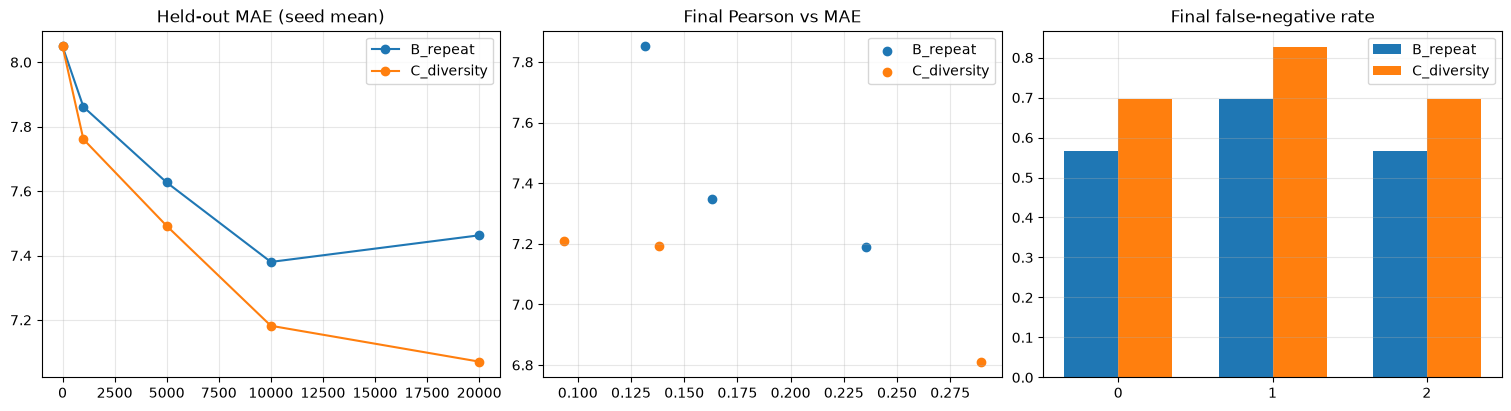

Saved: /Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/scenario_diversity_confirmation


In [8]:
finals={branch:[all_results[(branch,s)][-1] for s in COST_CRITIC_SEEDS] for branch in ('B_repeat','C_diversity')}
metrics=['mae','rmse','pearson','spearman','false_negative_rate','false_positive_rate','coverage']
aggregate={}
for branch,rows in finals.items():
    aggregate[branch]={k:{'mean':float(np.mean([r[k] for r in rows])),'median':float(np.median([r[k] for r in rows])),'values':[r[k] for r in rows]} for k in metrics}
aggregate['paired_C_minus_B']={k:[finals['C_diversity'][i][k]-finals['B_repeat'][i][k] for i in range(len(COST_CRITIC_SEEDS))] for k in metrics}
report={'design':{'B':'10 geometry/N x 10','C':'100 geometry/N x 1','validation':'20 geometry/N x 3','seeds':COST_CRITIC_SEEDS},'aggregate':aggregate,'final_by_seed':finals}
(OUTPUT_RUN/'final_report.json').write_text(json.dumps(report,indent=2),encoding='utf-8'); display(report)
fig,axes=plt.subplots(1,3,figsize=(15,4),constrained_layout=True)
for branch,color in [('B_repeat','tab:blue'),('C_diversity','tab:orange')]:
    means=[]
    for j in range(len(UPDATE_MILESTONES)): means.append(np.mean([all_results[(branch,s)][j]['mae'] for s in COST_CRITIC_SEEDS]))
    axes[0].plot(UPDATE_MILESTONES,means,marker='o',label=branch,color=color)
    axes[1].scatter([r['pearson'] for r in finals[branch]],[r['mae'] for r in finals[branch]],label=branch,color=color)
    axes[2].bar(np.arange(len(COST_CRITIC_SEEDS))+(0 if branch=='B_repeat' else .35),[r['false_negative_rate'] for r in finals[branch]],width=.35,label=branch,color=color)
axes[0].set_title('Held-out MAE (seed mean)'); axes[1].set_title('Final Pearson vs MAE'); axes[2].set_title('Final false-negative rate'); axes[2].set_xticks(np.arange(len(COST_CRITIC_SEEDS))+.175,COST_CRITIC_SEEDS)
for ax in axes: ax.grid(alpha=.3); ax.legend()
fig.savefig(OUTPUT_RUN/'diversity_confirmation.png',dpi=170); plt.show(); print('Saved:',OUTPUT_RUN)